In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
import os
from pathlib import Path



In [21]:

project_dir = str(Path("/Users/ramzyalmulla/research/smearlab/keypoint_moseq_2208_t1_raw/"))
config = lambda: kpms.load_config(project_dir)

In [22]:
base_path_str = "/Volumes/CrucialRZA/smearlab/clickbait-loco/thermister/"
sleap_file = str(Path(base_path_str+"2208/t1/04122026_2208_t1_raw.slp"))  # any .slp or .h5 file with predictions for a single video
sleap_dir = str(Path(base_path_str+"2208/t1/"))
video_dir = str(Path(base_path_str+"2208/t1/"))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
if not os.path.exists(project_dir):
    kpms.setup_project(project_dir, sleap_file=sleap_file,video_dir=video_dir) 


In [23]:
# load data 
keypoint_data_path = sleap_file  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

Loading keypoints: 100%|██████████████████| 1/1 [00:07<00:00,  7.58s/it]

Coordinates for the following bodyparts are missing (set to NaN) in at least 50.0% of frames:
 - forepawR1

This may cause problems during modeling. See https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#high-proportion-of-nans for additional information.

In [45]:
coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


In [46]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [47]:
# %matplotlib ipympl
# kpms.noise_calibration(project_dir, coordinates, confidences, **config())


>=90.0% of variance exlained by 6 components.


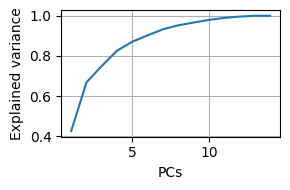

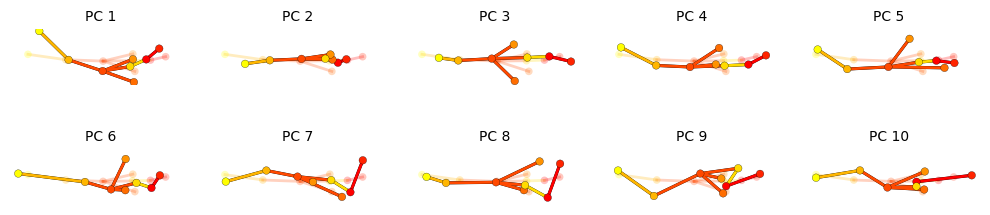

In [48]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

In [49]:
kpms.update_config(project_dir, latent_dim=9)

In [50]:
kpms.update_config(
    project_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

In [51]:
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


In [52]:
# initialize the model
model = kpms.init_model(data, pca=pca, **config())

# # optionally modify kappa
model = kpms.update_hypparams(model, kappa=1e10)

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_2208_t1_raw/2026_04_16-19_13_58


 49%|█████████████████▏                 | 25/51 [00:53<00:54,  2.09s/it]

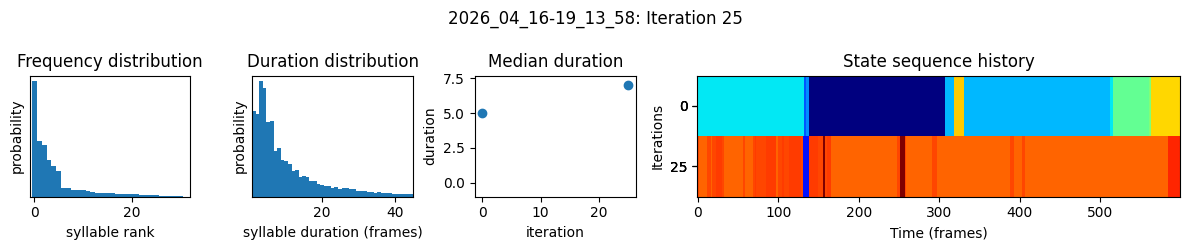

 98%|██████████████████████████████████▎| 50/51 [01:47<00:02,  2.13s/it]

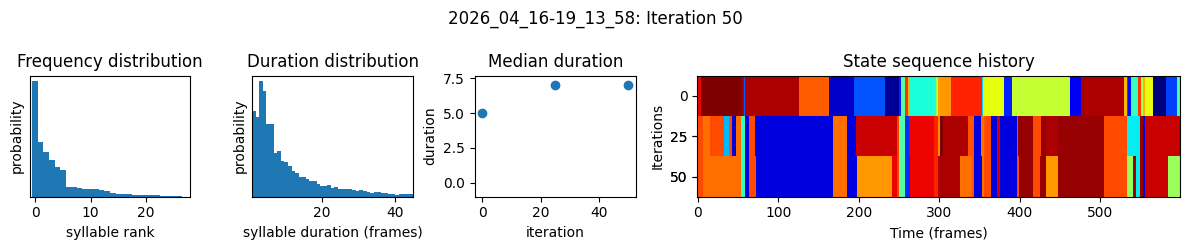

100%|███████████████████████████████████| 51/51 [01:49<00:00,  2.15s/it]


In [53]:
num_ar_iters = 50

model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, jitter=1e-2,ar_only=True, num_iters=num_ar_iters
)

Outputs will be saved to /Users/ramzyalmulla/research/smearlab/keypoin
t_moseq_2208_t1_raw/2026_04_16-19_13_58


  5%|█▌                                | 25/551 [00:54<18:58,  2.16s/it]

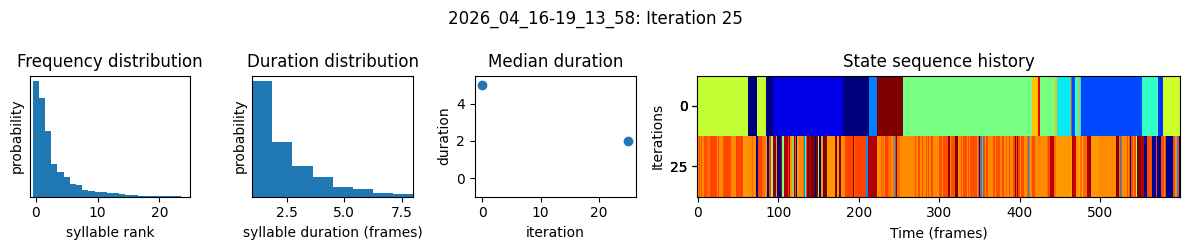

  9%|███                               | 50/551 [01:48<18:52,  2.26s/it]

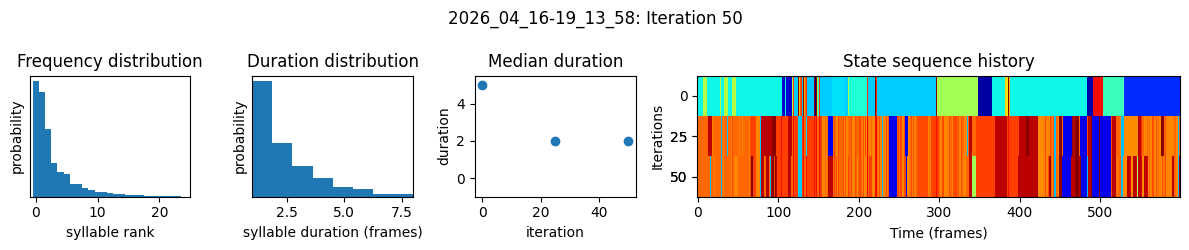

 14%|████▋                             | 75/551 [02:43<17:06,  2.16s/it]

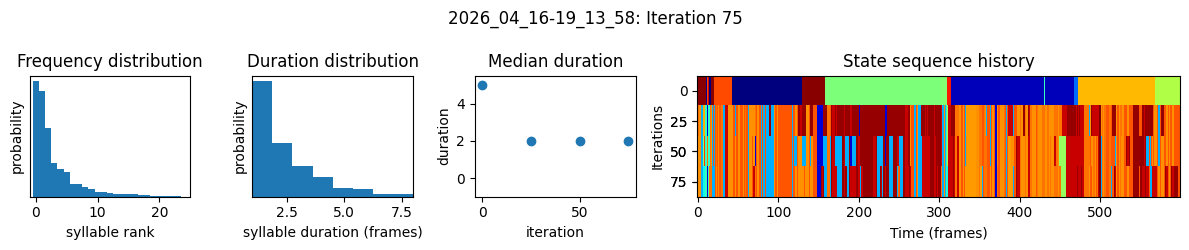

 18%|█████▉                           | 100/551 [03:39<16:22,  2.18s/it]

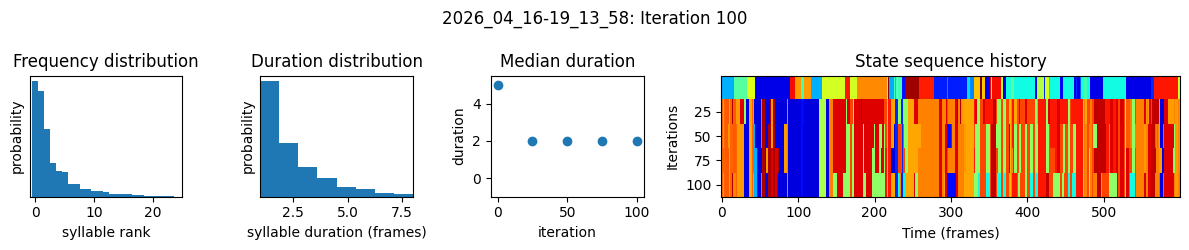

 23%|███████▍                         | 125/551 [04:35<15:29,  2.18s/it]

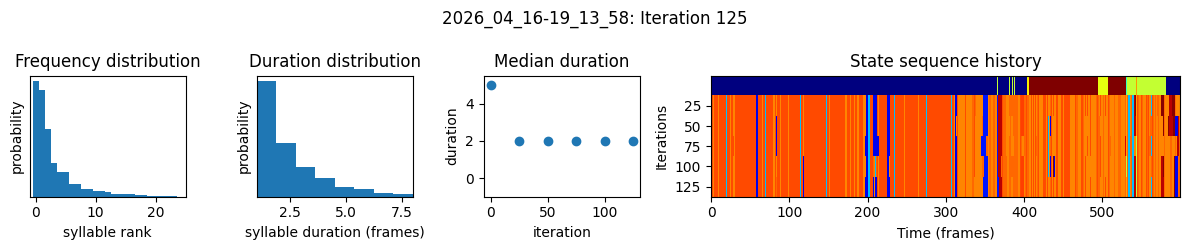

 27%|████████▉                        | 150/551 [05:30<14:55,  2.23s/it]

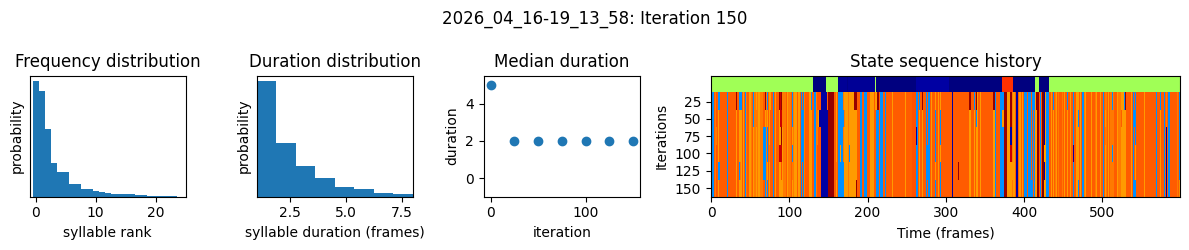

 32%|██████████▍                      | 175/551 [06:25<14:06,  2.25s/it]

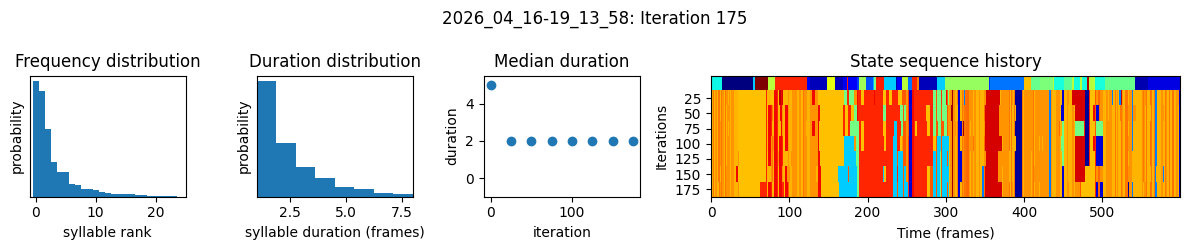

 36%|███████████▉                     | 200/551 [07:19<12:24,  2.12s/it]

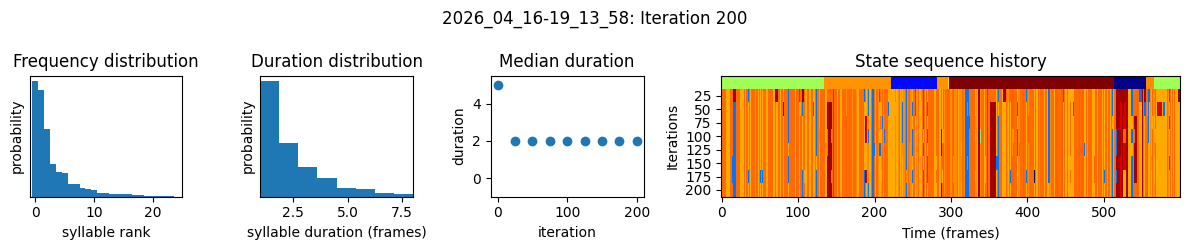

 41%|█████████████▍                   | 225/551 [08:14<11:27,  2.11s/it]

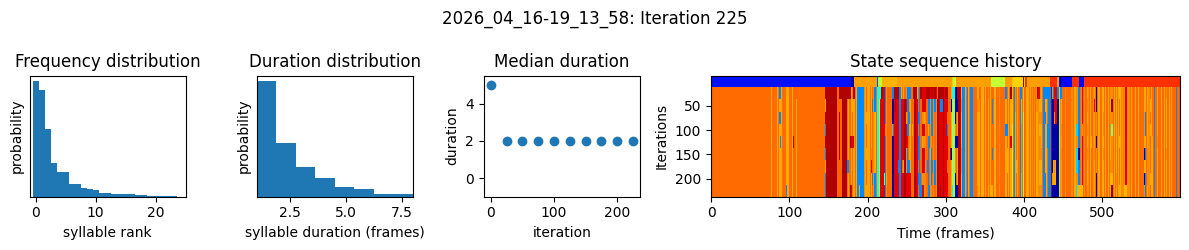

 42%|██████████████                   | 234/551 [08:37<11:40,  2.21s/it]


KeyboardInterrupt: 

In [54]:

# load model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(
    project_dir, model_name, iteration=num_ar_iters
)
# modify kappa to maintain the desired syllable time-scale
model = kpms.update_hypparams(model, kappa=1e5)

# run fitting for an additional 500 iters
model = kpms.fit_model(
    model,
    data,
    metadata,
    project_dir,
    model_name,
    jitter=1e-2,
    ar_only=True,
    num_iters=current_iter+500
)

In [ ]:
# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

Reindexing: 100%|███████████| 23/23 [00:00<00:00, 98.68model snapshot/s]


In [ ]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

Saved results to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_
2208_t1/2026_04_16-19_01_09/results.h5


Saving trajectory plots to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2208_t1/2026_04_16-19_01_09/trajectory_plots


Generating trajectory plots: 100%|██████| 17/17 [00:02<00:00,  6.62it/s]


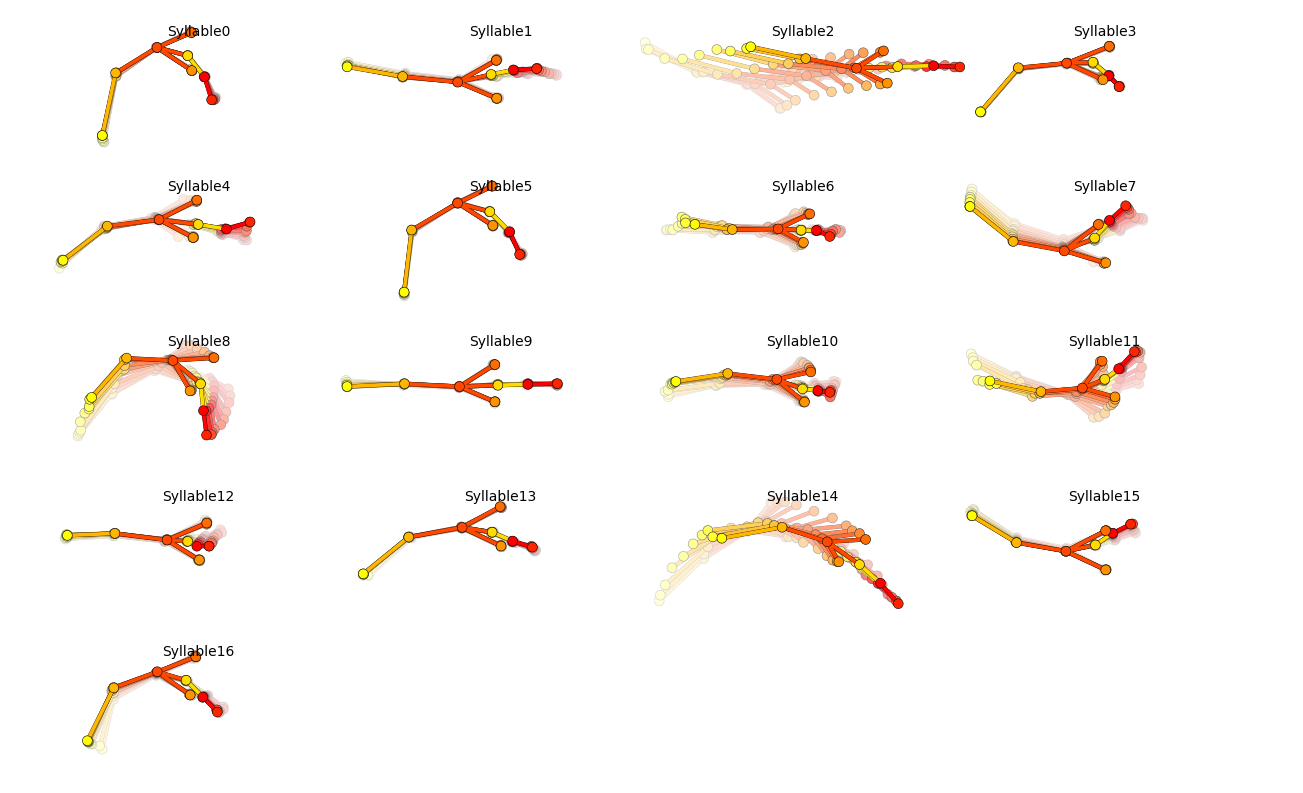

In [ ]:
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, project_dir, model_name, **config())


Saving dendrogram plot to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2208_t1/2026_04_16-19_01_09/similarity_dendrogram


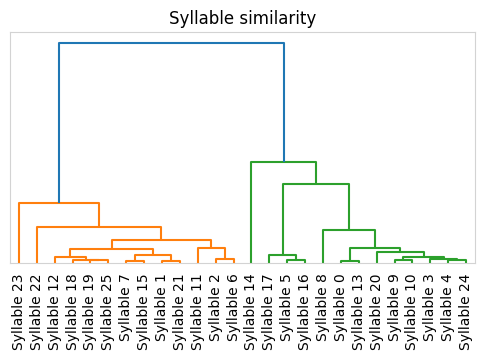

In [ ]:
kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name, **config())

In [ ]:
kpms.generate_grid_movies(results, project_dir, model_name, coordinates=coordinates, **config());

Writing grid movies to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2208_t1/2026_04_16-19_01_09/grid_movies



Videos will be downscaled by a factor of 0.95 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.



Using window size of 336 pixels


Generating grid movies:  57%|██████▎    | 12/21 [02:16<01:42, 11.41s/it]os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


KeyboardInterrupt: 